# **Analisis dan Pengembangan Model Artificial Neural Network (ANN) untuk Klasifikasi Handwritten Digits (0–9)**

## *1. Instalasi & Import Library*

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

## *2. Konfigurasi Kaggle API*

In [3]:
kaggle = "../data/kaggle.json"

## *3. Ekstraksi Dataset*

In [5]:
file_name = "../data/handwritten-digits-0-9.zip"

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print("done")

done


## *4. Eksplorasi Awal Dataset*

In [8]:
for i in range(10):
    jumlah = len(os.listdir(f'../data/dataset/{i}'))
    print(f"Jumlah data kelas {i}: {jumlah}")

Jumlah data kelas 0: 2236
Jumlah data kelas 1: 2241
Jumlah data kelas 2: 2233
Jumlah data kelas 3: 2202
Jumlah data kelas 4: 2179
Jumlah data kelas 5: 2126
Jumlah data kelas 6: 2121
Jumlah data kelas 7: 2116
Jumlah data kelas 8: 2085
Jumlah data kelas 9: 2016


In [10]:
data_0 = os.listdir('../data/dataset/0')
len(data_0)

2236

## *5. Preprocessing Data (Ubah ke Numerik)*

Proses:
*   Grayscale
*   Resize 28×28
*   Normalisasi (0–1)
*   Flatten (1D vector) 

In [11]:
X = []
y = []

dataset_path = "../data/dataset"

for label in range(10):
    folder = os.path.join(dataset_path, str(label))
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28, 28))
        img = img / 255.0
        img = img.flatten()

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (21555, 784)
Shape y: (21555,)


## *6. Split Data (Train-Test Split)*

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## 7. *Encoding Label (One-Hot Encoding)*

In [14]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

## 8. *Membangun Model ANN*

In [15]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

## *9. Compile Model*

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## *10. Train Model*

In [17]:
history = model.fit(
    X_train, y_train_cat,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.4732 - loss: 1.6214 - val_accuracy: 0.2852 - val_loss: 3.0617
Epoch 2/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6625 - loss: 1.0585 - val_accuracy: 0.1925 - val_loss: 5.0222
Epoch 3/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7301 - loss: 0.8384 - val_accuracy: 0.3217 - val_loss: 2.9171
Epoch 4/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.7650 - loss: 0.7281 - val_accuracy: 0.3965 - val_loss: 2.4382
Epoch 5/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7890 - loss: 0.6441 - val_accuracy: 0.2168 - val_loss: 3.9897
Epoch 6/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8024 - loss: 0.5988 - val_accuracy: 0.2725 - val_loss: 4.9833
Epoch 7/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8195 - loss: 0.5573 - val_accuracy: 0.1878 - val_loss: 7.0238
Epoch 8/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8301 - loss: 0.5215 - val_a

## *11. Visualisasi Accuracy & Loss*

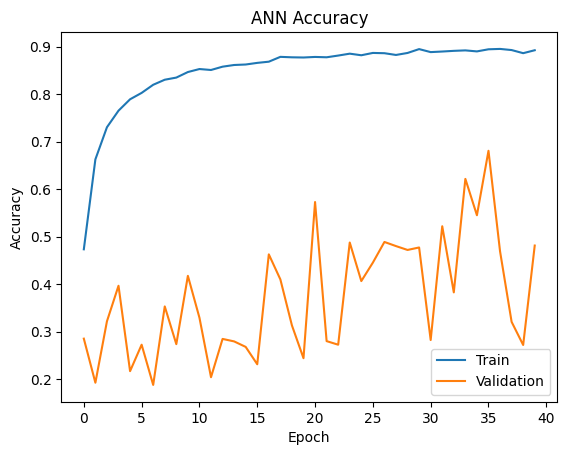

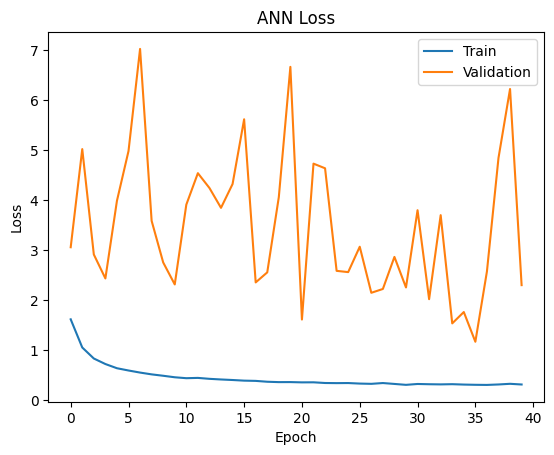

In [18]:
#accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.title('ANN Accuracy')
plt.show()

#loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('ANN Loss')
plt.show()

## *12. Evaluasi Model*

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


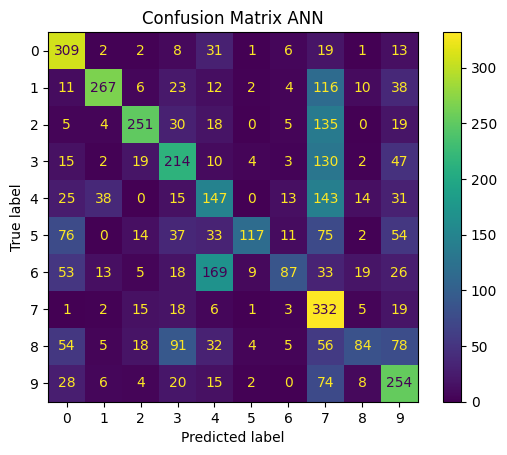

In [19]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix ANN")
plt.show()